# 1. Land Surface Temperature Summer vs Winter

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load data
df = pd.read_csv("C:/Users/percy/Documents/studies/visual_studio_code/PhD_chapter2_IGARSS/data/csv/lst_zonal_lc_season_csv.csv")

# Add Temperature difference between Winter and winter
# ensure clean data
df = df.copy()


# reshape so winter and Winter become columns
df_pivot = df.pivot_table(
    index=["gridcode", "lc", "lc_0"],
    columns="season",
    values=["min", "max", "mean", "std", "median"]
)

# flatten column names
df_pivot.columns = ['_'.join(col) for col in df_pivot.columns]
df_pivot = df_pivot.reset_index()

# compute differences (winter - Winter)
df_pivot["min"] = df_pivot["min_Summer"] - df_pivot["min_Winter"]
df_pivot["max"] = df_pivot["max_Summer"] - df_pivot["max_Winter"]
df_pivot["mean"] = df_pivot["mean_Summer"] - df_pivot["mean_Winter"]
df_pivot["std"] = df_pivot["std_Summer"] - df_pivot["std_Winter"]
df_pivot["median"] = df_pivot["median_Summer"] - df_pivot["median_Winter"]

# add season label
df_pivot["season"] = "Summer - Winter"

# final output
df_diff = df_pivot[["season",
    "gridcode", "lc", "lc_0",
    "min", "max", "mean",
    "std", "median"
]]


In [3]:
# concat df with df_diff
df = pd.concat([df, df_diff], axis=0, ignore_index=True)

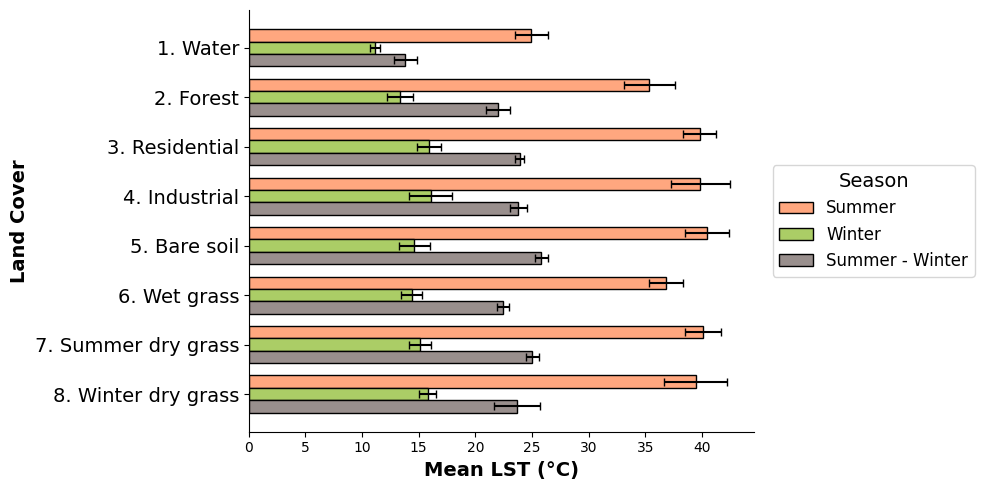

In [39]:
# Colors
lc_colors = {
    "Summer": "#FFA77F",
    "Winter": "#ABCD66",
    "Summer - Winter": "#998F8D"
}

# Categories
lc_categories = sorted(df["lc"].unique())
seasons = ["Summer", "Winter", "Summer - Winter"]

# y positions (because LC is now vertical axis)
y = np.arange(len(lc_categories))
height = 0.25

plt.figure(figsize=(10, 5))

for i, season in enumerate(seasons):
    subset = df[df["season"] == season]

    means = []
    stds = []

    for lc in lc_categories:
        row = subset[subset["lc"] == lc]

        if not row.empty:
            means.append(row["mean"].values[0])
            stds.append(row["std"].values[0])
        else:
            means.append(np.nan)
            stds.append(np.nan)

    plt.barh(
        y + i * height - height,
        means,
        height,
        label=season,
        color=lc_colors[season],
        edgecolor="black"
    )

    plt.errorbar(
        means,
        y + i * height - height,
        xerr=stds,
        fmt="none",
        ecolor="black",
        capsize=3
    )

# Labels
plt.xlabel("Mean LST (°C)", fontsize=14, fontweight="bold")
plt.ylabel("Land Cover", fontsize=14, fontweight="bold")

plt.yticks(y, lc_categories, fontsize=14)
plt.gca().invert_yaxis()


plt.legend(title="Season", fontsize=12, title_fontsize=14)

# Clean style
ax = plt.gca()
ax.set_facecolor("white")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.legend(
    title="Season",
    fontsize=12,
    title_fontsize=14,
    loc="center left",          # anchor legend by its left side
    bbox_to_anchor=(1.02, 0.5), # push it to the right of the plot
    ncol=1                      # stack items vertically (usually better on the side)
)

plt.tight_layout()

# Save
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/PhD_chapter2_IGARSS/output/figures/lst_summer_winter_difference_land_cover.png", dpi=300, bbox_inches="tight")

plt.show()

# 2. Turning Points
**Objective**
Identify local maxima or minima (turning points) in the smoothed LST profile along buffer distances.

---

**Method**

1. **Smoothing**  
   Fit a cubic smoothing spline to the LST profile to reduce noise and capture the underlying trend.

2. **Gradient computation**  
   Compute the difference between consecutive smoothed values:
   $$
   \Delta T_i = LST_{i+1} - LST_i
   $$

3. **Threshold definition**  
   Define a threshold to avoid detecting minor fluctuations:
   $$
   \Delta T_{\text{threshold}} = \text{Pert} \times (T_{\max} - T_{\min})
   $$
   where:
   - **Pert** is a small proportion  
     - Summer: 0.003  
     - Winter: 0.002  
   - $T_{\max}$, $T_{\min}$ are the maximum and minimum LST values along the profile  

   > **Note:** The original study (Yang et al., 2026) used $\text{Pert} = 0.02$ with MODIS (1 km resolution).  
   > Here, a smaller value is applied due to the higher spatial resolution of Landsat (30 m), as supported by sensitivity analysis.

4. **Turning point detection**  
   Identify the first location where:
   - the gradient changes sign:
     $$
     \Delta T_k \cdot \Delta T_{k+1} \leq 0
     $$
   - and the magnitude exceeds the defined threshold  

   This point corresponds to a **turning point** (local maximum or minimum).

---


## 2.1 Summer

In [4]:
# Import necessary libraries
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(sys.executable)
print(pd.__version__)

c:\Users\percy\Documents\studies\visual_studio_code\PhD_chapter2_IGARSS\.venv\Scripts\python.exe
1.3.5


In [5]:
# Load the gradient metadata from the CSV file
gradient_metadata = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD_chapter2_IGARSS\data\csv\constructed_buffer_metadata_500.csv")

# View the first 5 rows of the gradient metadata
print(gradient_metadata.head())

   direction  buffer_no  buffer_id
0        285          0          1
1        285          2          2
2        285          3          3
3        285          4          4
4        285          5          5


In [6]:
# Load the mean SUMMER LST data from the CSV file
summer_lst = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD_chapter2_IGARSS\data\csv\lst_2023_500m.csv")

# View the first 5 rows
print(summer_lst.head())

   buffer_id   lst_mean
0          1  40.433142
1          2  40.640523
2          3  40.705170
3          4  40.699824
4          5  40.784971


In [7]:
# Join the summer_lst DataFrame with the gradient metadata DataFrame on the buffer_id column
summer_lst_gradient = pd.merge(summer_lst, gradient_metadata, on='buffer_id')

# Keep only desired columns
summer_lst_gradient = summer_lst_gradient[["buffer_id", "buffer_no", "direction", "lst_mean"]]

# View the first 5 rows of the joined DataFrame
print(summer_lst_gradient.head(10))

# save the joined DataFrame to a new CSV file
summer_lst_gradient.to_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD_chapter2_IGARSS\data\csv\summer_lst_gradient_csv.csv", index=False)

   buffer_id  buffer_no  direction   lst_mean
0          1          0        285  40.433142
1          2          2        285  40.640523
2          3          3        285  40.705170
3          4          4        285  40.699824
4          5          5        285  40.784971
5          6          6        285  40.848209
6          7          7        285  41.244442
7          8          8        285  40.717113
8          9          9        285  40.345187
9         10         10        285  40.837724


In [8]:
import pandas as pd
import numpy as np
from scipy.interpolate import UnivariateSpline

# --------------------------
# 1. Filter directions
# --------------------------
summer_lst_gradient = summer_lst_gradient[summer_lst_gradient["direction"].isin([285, 315, 345])]

summer_df_spline_list = []
summer_turning_points = []

# --------------------------
# 2. Loop per direction
# --------------------------
for direction, group in summer_lst_gradient.groupby("direction"):
    
    group = group.sort_values("buffer_no")
    
    x = group["buffer_no"].values
    y = group["lst_mean"].values
    
    # --------------------------
    # 3. Cubic smoothing spline
    # --------------------------
    # s controls smoothing strength (tune this!)
    s_value = len(x) * np.var(y) * 0.1   # good starting point
    spline = UnivariateSpline(x, y, k=3, s=s_value)
    
    pred = spline(x)
    
    # Force exact value at distance = 0
    idx0 = np.where(x == 0)[0]
    if len(idx0):
        pred[idx0[0]] = y[idx0[0]]
    
    # Store smoothed curve
    summer_df_spline_list.append(pd.DataFrame({
        "buffer_no": x,
        "lst_mean": pred,
        "direction": direction
    }))
    
print("Rows:", len(summer_lst_gradient))
print("Columns:", summer_lst_gradient.columns)
print("Unique directions:", summer_lst_gradient["direction"].unique())
print(summer_lst_gradient.groupby("direction").size())


Rows: 72
Columns: Index(['buffer_id', 'buffer_no', 'direction', 'lst_mean'], dtype='object')
Unique directions: [285 315 345]
direction
285    18
315    32
345    22
dtype: int64


In [9]:
import pandas as pd
import numpy as np
from scipy.interpolate import UnivariateSpline

# --------------------------
# 1. Filter directions
# --------------------------
summer_lst_gradient = summer_lst_gradient[summer_lst_gradient["direction"].isin([285, 315, 345])]

# Store smoothed curves
summer_df_spline_list = []

# Scaling factors to test
scaling_factors = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01]

# Store TP results
sensitivity_results = []

# --------------------------
# 2. Loop per direction
# --------------------------
for direction, group in summer_lst_gradient.groupby("direction"):
    
    group = group.sort_values("buffer_no")
    
    x = group["buffer_no"].values
    y = group["lst_mean"].values
    
    # --------------------------
    # 3. Cubic smoothing spline
    # --------------------------
    s_value = len(x) * np.var(y) * 0.1   # smoothing parameter
    spline = UnivariateSpline(x, y, k=3, s=s_value)
    pred = spline(x)
    
    # Force exact value at distance = 0
    idx0 = np.where(x == 0)[0]
    if len(idx0):
        pred[idx0[0]] = y[idx0[0]]
    
    # Store smoothed curve
    summer_df_spline_list.append(pd.DataFrame({
        "buffer_no": x,
        "lst_mean": pred,
        "direction": direction
    }))
    
    # --------------------------
    # 4. Compute differences
    # --------------------------
    delta_T = np.diff(pred)
    
    # --------------------------
    # 5. Sensitivity analysis for each scaling factor
    # --------------------------
    for sf in scaling_factors:
        T_max, T_min = np.max(pred), np.min(pred)
        threshold = sf * (T_max - T_min)
        
        tp_index = None
        for k in range(len(delta_T) - 1):
            if abs(delta_T[k]) > threshold and (abs(delta_T[k+1]) <= threshold or delta_T[k]*delta_T[k+1] <= 0):
                tp_index = k + 1  # +1 because diff reduces length by 1
                break
        
        sensitivity_results.append({
            "direction": direction,
            "scaling_factor": sf,
            "turning_point_buffer": tp_index
        })

# --------------------------
# 6. Convert to DataFrame for inspection
# --------------------------
sensitivity_df = pd.DataFrame(sensitivity_results)

# Example summary: number of directions with valid TP per scaling factor
summary = sensitivity_df.groupby("scaling_factor")["turning_point_buffer"].apply(lambda x: x.notnull().sum()).reset_index()
summary.rename(columns={"turning_point_buffer": "num_valid_directions"}, inplace=True)
print(summary)

# Optional: full table
print(sensitivity_df)

# Save sensitivity results to CSV
sensitivity_df.to_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD_chapter2_IGARSS\output\table\sensitivity_analysis_turning_points.csv", index=False)


   scaling_factor  num_valid_directions
0           0.001                     3
1           0.002                     3
2           0.003                     3
3           0.004                     3
4           0.005                     3
5           0.006                     3
6           0.007                     3
7           0.008                     3
8           0.009                     3
9           0.010                     3
    direction  scaling_factor  turning_point_buffer
0         285           0.001                     2
1         285           0.002                     2
2         285           0.003                     2
3         285           0.004                     2
4         285           0.005                     2
5         285           0.006                     2
6         285           0.007                     2
7         285           0.008                     2
8         285           0.009                     2
9         285           0.010           

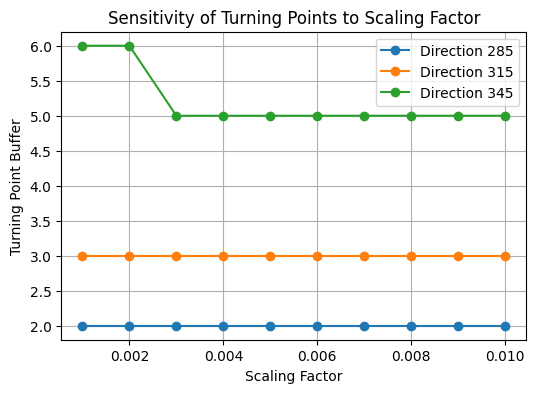

In [10]:
# Plot Scaling Factor vs Turning Point Buffer Index
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
# use the DataFrame created in the previous step or load it from the CSV if needed
data = sensitivity_df


plt.figure(figsize=(6,4))

for direction in data['direction'].unique():
    subset = data[data['direction'] == direction]
    plt.plot(subset['scaling_factor'], subset['turning_point_buffer'], marker='o', label=f"Direction {direction}")

plt.xlabel("Scaling Factor")
plt.ylabel("Turning Point Buffer")
plt.title("Sensitivity of Turning Points to Scaling Factor")
plt.grid(True)
plt.legend()
plt.show()


In [11]:
import pandas as pd
import numpy as np
from scipy.interpolate import UnivariateSpline

summer_df_spline_list = []
summer_turning_points = []

for direction, group in summer_lst_gradient.groupby("direction"):
    
    # Safety: ensure enough points
    if len(group) < 4:
        print(f"Skipping direction {direction} (not enough points)")
        continue
    
    group = group.sort_values("buffer_no")
    
    x = group["buffer_no"].values
    y = group["lst_mean"].values
    
    # --------------------------
    # Cubic smoothing spline
    # --------------------------
    s_value = len(x) * np.var(y) * 0.1
    spline = UnivariateSpline(x, y, k=3, s=s_value)
    
    pred = spline(x)
    
     
    # Store smoothed curve
    summer_df_spline_list.append(pd.DataFrame({
        "buffer_no": x,
        "lst_mean": pred,
        "direction": direction
    }))
    
    # --------------------------
    # Turning point detection
    # --------------------------
    delta_T = np.diff(pred)
    
    Tmax = np.max(pred)
    Tmin = np.min(pred)
    
    delta_Tt = 0.003 * (Tmax - Tmin)
    
    found = False
    
    for k in range(len(delta_T) - 1):
        
        cond1 = abs(delta_T[k]) > delta_Tt
        cond2 = delta_T[k] * delta_T[k+1] <= 0
        
        if cond1 and cond2:
            summer_turning_points.append({
                "direction": direction,
                "buffer_no": x[k],
                "lst": pred[k]
            })
            found = True
            break
    
    # Optional: track if no turning point found
    if not found:
        print(f"No turning point found for direction {direction}")

# --------------------------
# Combine outputs safely
# --------------------------
if summer_df_spline_list:
    summer_df_spline = pd.concat(summer_df_spline_list, ignore_index=True)
else:
    summer_df_spline = pd.DataFrame()

summer_df_turning = pd.DataFrame(summer_turning_points)

print(summer_df_turning)


   direction  buffer_no        lst
0        285          1  40.811434
1        315          2  39.000351
2        345          8  37.785334


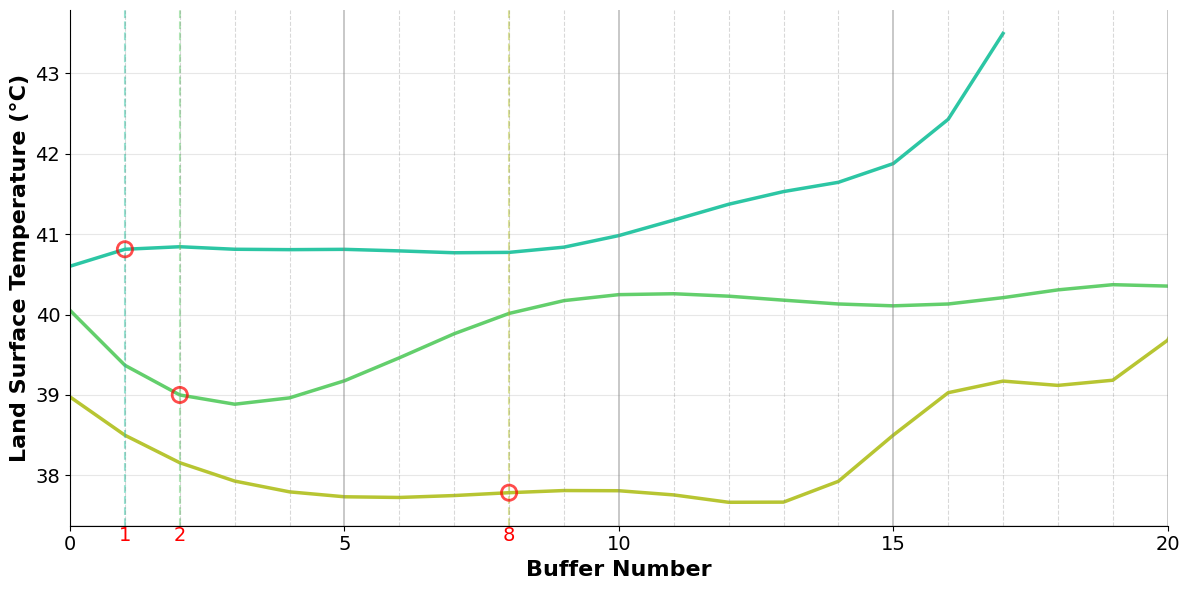

In [38]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# --------------------------
# Colors (integer keys)
# --------------------------
colors = {
    285: "#2cc6a4",
    315: "#63cf6c",
    345: "#b7c532"
}

plt.figure(figsize=(12, 6))
ax = plt.gca()

# --------------------------
# 1. Plot smoothed curves
# --------------------------
for direction, group in summer_df_spline.groupby("direction"):
    if direction in colors:
        plt.plot(
            group["buffer_no"],
            group["lst_mean"],
            linewidth=2.5,
            color=colors[direction],
            label=f"{direction}°"
        )

# --------------------------
# 2. Plot turning points (colored by direction, semi-transparent)
# --------------------------
turn_x = summer_df_turning["buffer_no"].tolist()
turn_y = summer_df_turning["lst"].tolist()
turn_dir = summer_df_turning["direction"].tolist()

for x_val, y_val, direction in zip(turn_x, turn_y, turn_dir):
    dir_color = colors.get(direction, "black")
    # Point
    plt.scatter(
        x_val,
        y_val,
        s=120,
        facecolor='none',   
        edgecolor="red",       # 🔴 red outline
        linewidth=2,           # make outline clearly visible
        alpha=0.7,
        zorder=6
    )
    # Annotate x-value at turning point
    plt.text(
        x_val,
        ax.get_ylim()[0],              # place near x-axis
        f"{x_val}",
        color="red",
        fontsize=14,
        ha='center',
        va='top',
        rotation=0                   # vertical text (cleaner)
    )

    # Vertical dashed line at turning point
    plt.axvline(
        x=x_val,
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        color=dir_color
    )

# --------------------------
# 3. X-axis vertical lines
# --------------------------
x_values = np.arange(0, 21, 1)
solid_lines = [5, 10, 15, 20]

for x in x_values:
    if x in solid_lines:
        ax.axvline(x=x, linestyle='-', color='grey', alpha=0.5, linewidth=1.2)
    else:
        ax.axvline(x=x, linestyle='--', color='grey', alpha=0.3, linewidth=0.8)

# --------------------------
# 4. Gray horizontal line along x-axis
# --------------------------
plt.axhline(y=ax.get_ylim()[0], color='grey', linewidth=1)

# --------------------------
# 5. Labels
# --------------------------
plt.xlabel("Buffer Number", fontsize=16, fontweight="bold")
plt.ylabel("Land Surface Temperature (°C)", fontsize=16, fontweight="bold")
ax.set_xlim(0, 20)
ax.set_xticks(np.arange(0, 21, 5))  # default ticks
ax.tick_params(axis='both', labelsize=14)


# --------------------------
# 6. Grid + background styling
# --------------------------
plt.grid(axis='y', alpha=0.3)
ax.set_facecolor("white")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# --------------------------
# 7. Legend
# --------------------------
legend_elements = [
    Line2D([0], [0], color=colors[285], lw=2.5, label="285° (W)"),
    Line2D([0], [0], color=colors[315], lw=2.5, label="315° (NW)"),
    Line2D([0], [0], color=colors[345], lw=2.5, label="345° (N)"),
    Line2D([0], [0], marker='o', color='w', label='Turning point',
           markerfacecolor='none', markeredgecolor='red', markeredgewidth=2, markersize=10)
]
#plt.legend(handles=legend_elements, title="Direction", fontsize=12, title_fontsize=13)

# --------------------------
# 8. Layout + Save
# --------------------------
plt.tight_layout()
plt.savefig(
    "C:/Users/percy/Documents/studies/visual_studio_code/PhD_chapter2_IGARSS/output/figures/summer_turning_points_spline.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 2.2 Winter

In [19]:

winter_lst = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD_chapter2_IGARSS\data\csv\lst_2022_500m.csv")

# View the first 5 rows
print(winter_lst.head())

   buffer_id  lst_mean
0          1   16.2452
1          2   15.4657
2          3   15.5092
3          4   15.7256
4          5   15.5961


In [21]:
# Join the winter_lst DataFrame with the gradient metadata DataFrame on the buffer_id column
winter_lst_gradient = pd.merge(winter_lst, gradient_metadata, on='buffer_id')

# Keep only desired columns
winter_lst_gradient = winter_lst_gradient[["buffer_id", "buffer_no", "direction", "lst_mean"]]

# View the first 5 rows of the joined DataFrame
print(winter_lst_gradient.head(10))

# save the joined DataFrame to a new CSV file
winter_lst_gradient.to_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD_chapter2_IGARSS\data\csv\winter_lst_gradient_csv.csv", index=False)

   buffer_id  buffer_no  direction  lst_mean
0          1          0        285   16.2452
1          2          2        285   15.4657
2          3          3        285   15.5092
3          4          4        285   15.7256
4          5          5        285   15.5961
5          6          6        285   15.6098
6          7          7        285   15.6920
7          8          8        285   15.8415
8          9          9        285   15.6679
9         10         10        285   15.6160


In [22]:
import pandas as pd
import numpy as np
from scipy.interpolate import UnivariateSpline

# --------------------------
# 1. Filter directions
# --------------------------
winter_lst_gradient = winter_lst_gradient[winter_lst_gradient["direction"].isin([285, 315, 345])]

winter_df_spline_list = []
winter_turning_points = []

# --------------------------
# 2. Loop per direction
# --------------------------
for direction, group in winter_lst_gradient.groupby("direction"):
    
    group = group.sort_values("buffer_no")
    
    x = group["buffer_no"].values
    y = group["lst_mean"].values
    
    # --------------------------
    # 3. Cubic smoothing spline
    # --------------------------
    # s controls smoothing strength (tune this!)
    s_value = len(x) * np.var(y) * 0.1   # good starting point
    spline = UnivariateSpline(x, y, k=3, s=s_value)
    
    pred = spline(x)
    
    # Force exact value at distance = 0
    idx0 = np.where(x == 0)[0]
    if len(idx0):
        pred[idx0[0]] = y[idx0[0]]
    
    # Store smoothed curve
    winter_df_spline_list.append(pd.DataFrame({
        "buffer_no": x,
        "lst_mean": pred,
        "direction": direction
    }))
    
print("Rows:", len(winter_lst_gradient))
print("Columns:", winter_lst_gradient.columns)
print("Unique directions:", winter_lst_gradient["direction"].unique())
print(winter_lst_gradient.groupby("direction").size())


Rows: 72
Columns: Index(['buffer_id', 'buffer_no', 'direction', 'lst_mean'], dtype='object')
Unique directions: [285 315 345]
direction
285    18
315    32
345    22
dtype: int64


In [23]:
import pandas as pd
import numpy as np
from scipy.interpolate import UnivariateSpline

# Sensitiive analysis for turning point detection
# --------------------------
# 1. Filter directions
# --------------------------
winter_lst_gradient = winter_lst_gradient[winter_lst_gradient["direction"].isin([285, 315, 345])]

# Store smoothed curves
winter_df_spline_list = []

# Scaling factors to test
scaling_factors = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01]

# Store TP results
sensitivity_results = []

# --------------------------
# 2. Loop per direction
# --------------------------
for direction, group in winter_lst_gradient.groupby("direction"):
    
    group = group.sort_values("buffer_no")
    
    x = group["buffer_no"].values
    y = group["lst_mean"].values
    
    # --------------------------
    # 3. Cubic smoothing spline
    # --------------------------
    s_value = len(x) * np.var(y) * 0.1   # smoothing parameter
    spline = UnivariateSpline(x, y, k=3, s=s_value)
    pred = spline(x)
    
    # Force exact value at distance = 0
    idx0 = np.where(x == 0)[0]
    if len(idx0):
        pred[idx0[0]] = y[idx0[0]]
    
    # Store smoothed curve
    winter_df_spline_list.append(pd.DataFrame({
        "buffer_no": x,
        "lst_mean": pred,
        "direction": direction
    }))
    
    # --------------------------
    # 4. Compute differences
    # --------------------------
    delta_T = np.diff(pred)
    
    # --------------------------
    # 5. Sensitivity analysis for each scaling factor
    # --------------------------
    for sf in scaling_factors:
        T_max, T_min = np.max(pred), np.min(pred)
        threshold = sf * (T_max - T_min)
        
        tp_index = None
        for k in range(len(delta_T) - 1):
            if abs(delta_T[k]) > threshold and (abs(delta_T[k+1]) <= threshold or delta_T[k]*delta_T[k+1] <= 0):
                tp_index = k + 1  # +1 because diff reduces length by 1
                break
        
        sensitivity_results.append({
            "direction": direction,
            "scaling_factor": sf,
            "turning_point_buffer": tp_index
        })

# --------------------------
# 6. Convert to DataFrame for inspection
# --------------------------
sensitivity_df = pd.DataFrame(sensitivity_results)

# Example summary: number of directions with valid TP per scaling factor
summary = sensitivity_df.groupby("scaling_factor")["turning_point_buffer"].apply(lambda x: x.notnull().sum()).reset_index()
summary.rename(columns={"turning_point_buffer": "num_valid_directions"}, inplace=True)
print(summary)

# Optional: full table
print(sensitivity_df)

# Save sensitivity results to CSV
sensitivity_df.to_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD_chapter2_IGARSS\output\table\winter_sensitivity_analysis_turning_points.csv", index=False)


   scaling_factor  num_valid_directions
0           0.001                     3
1           0.002                     3
2           0.003                     3
3           0.004                     3
4           0.005                     3
5           0.006                     3
6           0.007                     3
7           0.008                     3
8           0.009                     3
9           0.010                     3
    direction  scaling_factor  turning_point_buffer
0         285           0.001                     4
1         285           0.002                     4
2         285           0.003                     4
3         285           0.004                     4
4         285           0.005                     4
5         285           0.006                     4
6         285           0.007                     4
7         285           0.008                     4
8         285           0.009                     4
9         285           0.010           

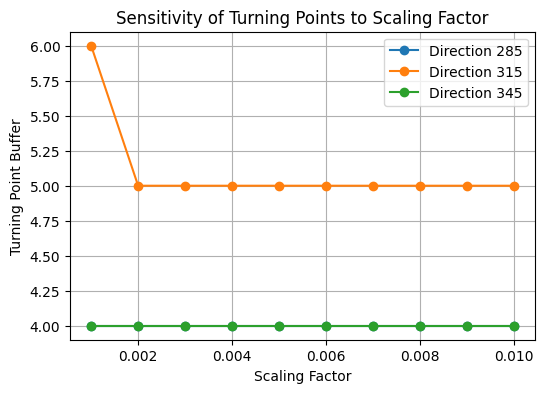

In [24]:
# Plot Scaling Factor vs Turning Point Buffer Index
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
# use the DataFrame created in the previous step or load it from the CSV if needed
data = sensitivity_df


plt.figure(figsize=(6,4))

for direction in data['direction'].unique():
    subset = data[data['direction'] == direction]
    plt.plot(subset['scaling_factor'], subset['turning_point_buffer'], marker='o', label=f"Direction {direction}")

plt.xlabel("Scaling Factor")
plt.ylabel("Turning Point Buffer")
plt.title("Sensitivity of Turning Points to Scaling Factor")
plt.grid(True)
plt.legend()
plt.show()


In [25]:
import pandas as pd
import numpy as np
from scipy.interpolate import UnivariateSpline

winter_df_spline_list = []
winter_turning_points = []

for direction, group in winter_lst_gradient.groupby("direction"):
    
    # Safety: ensure enough points
    if len(group) < 4:
        print(f"Skipping direction {direction} (not enough points)")
        continue
    
    group = group.sort_values("buffer_no")
    
    x = group["buffer_no"].values
    y = group["lst_mean"].values
    
    # --------------------------
    # Cubic smoothing spline
    # --------------------------
    s_value = len(x) * np.var(y) * 0.1
    spline = UnivariateSpline(x, y, k=3, s=s_value)
    
    pred = spline(x)
    
     
    # Store smoothed curve
    winter_df_spline_list.append(pd.DataFrame({
        "buffer_no": x,
        "lst_mean": pred,
        "direction": direction
    }))
    
    # --------------------------
    # Turning point detection
    # --------------------------
    delta_T = np.diff(pred)
    
    Tmax = np.max(pred)
    Tmin = np.min(pred)
    
    delta_Tt = 0.002 * (Tmax - Tmin)
    
    found = False
    
    for k in range(len(delta_T) - 1):
        
        cond1 = abs(delta_T[k]) > delta_Tt
        cond2 = delta_T[k] * delta_T[k+1] <= 0
        
        if cond1 and cond2:
            winter_turning_points.append({
                "direction": direction,
                "buffer_no": x[k],
                "lst": pred[k]
            })
            found = True
            break
    
    # Optional: track if no turning point found
    if not found:
        print(f"No turning point found for direction {direction}")

# --------------------------
# Combine outputs safely
# --------------------------
if winter_df_spline_list:
    winter_df_spline = pd.concat(winter_df_spline_list, ignore_index=True)
else:
    winter_df_spline = pd.DataFrame()

winter_df_turning = pd.DataFrame(winter_turning_points)

print(winter_df_turning)


   direction  buffer_no        lst
0        285          3  15.561421
1        315          8  14.859535
2        345          3  14.493817


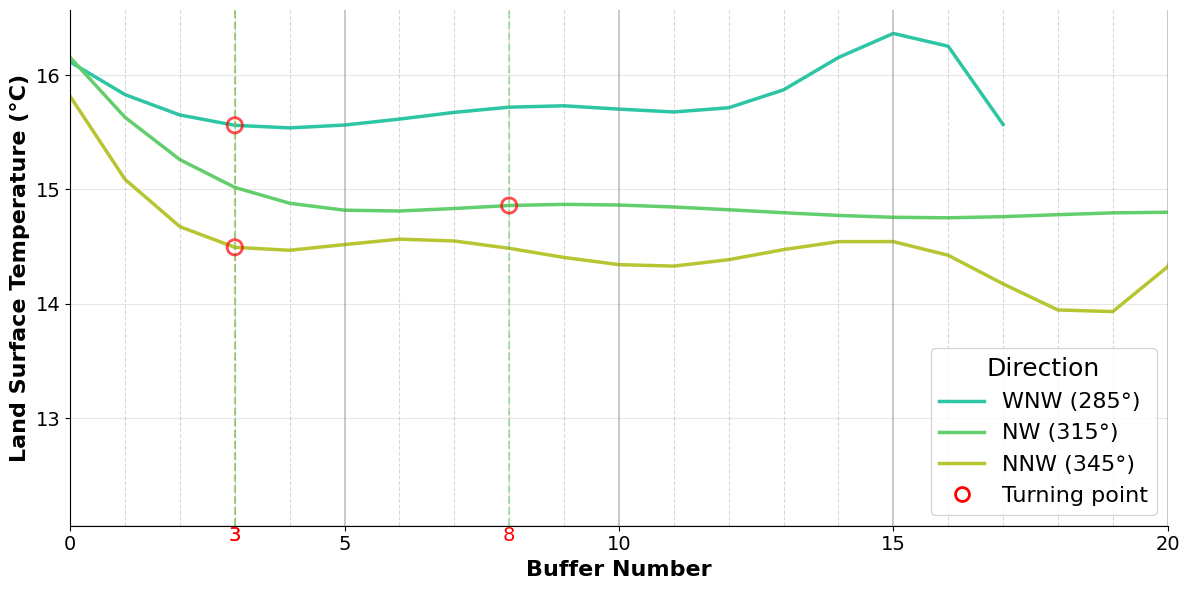

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# --------------------------
# Colors (integer keys)
# --------------------------
colors = {
    285: "#2cc6a4",
    315: "#63cf6c",
    345: "#b7c532"
}

plt.figure(figsize=(12, 6))
ax = plt.gca()

# --------------------------
# 1. Plot smoothed curves
# --------------------------
for direction, group in winter_df_spline.groupby("direction"):
    if direction in colors:
        plt.plot(
            group["buffer_no"],
            group["lst_mean"],
            linewidth=2.5,
            color=colors[direction],
            label=f"{direction}°"
        )

# --------------------------
# 2. Plot turning points (colored by direction, semi-transparent)
# --------------------------
turn_x = winter_df_turning["buffer_no"].tolist()
turn_y = winter_df_turning["lst"].tolist()
turn_dir = winter_df_turning["direction"].tolist()

for x_val, y_val, direction in zip(turn_x, turn_y, turn_dir):
    dir_color = colors.get(direction, "black")
    # Point
    plt.scatter(
        x_val,
        y_val,
        s=120,
        facecolor='none',   
        edgecolor="red",       # 🔴 red outline
        linewidth=2,           # make outline clearly visible
        alpha=0.7,
        zorder=6
    )
    # Annotate x-value at turning point
    plt.text(
        x_val,
        ax.get_ylim()[0],              # place near x-axis
        f"{x_val}",
        color="red",
        fontsize=14,
        ha='center',
        va='top',
        rotation=0                   # vertical text (cleaner)
    )

    # Vertical dashed line at turning point
    plt.axvline(
        x=x_val,
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        color=dir_color
    )

# --------------------------
# 3. X-axis vertical lines
# --------------------------
x_values = np.arange(0, 21, 1)
solid_lines = [5, 10, 15, 20]

for x in x_values:
    if x in solid_lines:
        ax.axvline(x=x, linestyle='-', color='grey', alpha=0.5, linewidth=1.2)
    else:
        ax.axvline(x=x, linestyle='--', color='grey', alpha=0.3, linewidth=0.8)


# --------------------------
# 4. Gray horizontal line along x-axis
# --------------------------
plt.axhline(y=ax.get_ylim()[0], color='grey', linewidth=1)

# --------------------------
# 5. Labels
# --------------------------
plt.xlabel("Buffer Number", fontsize=16, fontweight="bold")
plt.ylabel("Land Surface Temperature (°C)", fontsize=16, fontweight="bold")
ax.set_xlim(0, 20)
ax.set_xticks(np.arange(0, 21, 5))  # default ticks
ax.tick_params(axis='both', labelsize=14)

# --------------------------
# 6. Grid + background styling
# --------------------------
plt.grid(axis='y', alpha=0.3)
ax.set_facecolor("white")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# --------------------------
# 7. Legend
# --------------------------
legend_elements = [
   Line2D([0], [0], color=colors[285], lw=2.5, label="WNW (285°)"),
   Line2D([0], [0], color=colors[315], lw=2.5, label="NW (315°)"),
    Line2D([0], [0], color=colors[345], lw=2.5, label="NNW (345°)"),
    Line2D([0], [0], marker='o', color='w', label='Turning point',
           markerfacecolor='none', markeredgecolor='red', markeredgewidth=2, markersize=10)
]
plt.legend(handles=legend_elements, title="Direction", fontsize=16, title_fontsize=18)

# --------------------------
# 8. Layout + Save
# --------------------------
plt.tight_layout()
plt.savefig(
    "C:/Users/percy/Documents/studies/visual_studio_code/PhD_chapter2_IGARSS/output/figures/winter_turning_points_spline.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 3. References
Yang, Q., Ye, R., Chakraborty, T. C., Hu, T., & Liu, Y. (2026). Estimation of intensity, footprint, and capacity of surface urban heat islands using a direction-enhanced adaptive synchronous extraction (DEASE) method. Remote Sensing of Environment, 333, 115118. https://doi.org/https://doi.org/10.1016/j.rse.2025.115118 

